# Đánh giá nhánh rPPG (CAN v1) trên tập Test FF++ C23


In [34]:
import os, glob, random, json, time
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

CACHE_DIR = "/kaggle/input/datasets/thinhphan272/ffpp-c23-rppg-cache/ffpp_c23_rppg_cache"
SPLIT_JSON_DIR = "/kaggle/input/datasets/peiyuanzhang/ff-split"
MANIFEST_CSV = os.path.join(CACHE_DIR, "manifest_processed.csv")
WEIGHTS_PATH = "/kaggle/input/datasets/thinhphan272/trained-dffusionmodel-rppg-pth/rppg_can_branch/rppg_can_best.pth"
HISTORY_CSV = "/kaggle/input/datasets/thinhphan272/trained-dffusionmodel-rppg-pth/rppg_can_branch/train_history.csv"
OUT_DIR = "/kaggle/working"

CAN_IMG_SIZE = 72
CLIP_LEN_EVAL = 64
MIN_FRAMES = 50
DIFF_EPS = 1.0
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", DEVICE)


Device: cuda


In [35]:
manifest = pd.read_csv(MANIFEST_CSV)
manifest['out_dir'] = manifest['out_dir'].str.replace('/kaggle/working/ffpp_c23_rppg_cache', CACHE_DIR, regex=False)

manifest_ok = manifest[
    manifest["status"].isin(["ok", "skip_exists", "partial"]) & (manifest["n_frames"] >= MIN_FRAMES)
].reset_index(drop=True)

test_df  = manifest_ok[manifest_ok.split == "test"].reset_index(drop=True)
print(f"\nTest: {len(test_df)}")

def load_and_resize(path, size=CAN_IMG_SIZE):
    img = cv2.imread(path)
    if img is None:
        return np.zeros((size, size, 3), dtype=np.float32)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (size, size))
    return img.astype(np.float32)

def compute_normalized_diff(curr, prev, eps=DIFF_EPS):
    return (curr - prev) / (curr + prev + eps)

class CANEvalDataset(Dataset):
    def __init__(self, df, clip_len=CLIP_LEN_EVAL, img_size=CAN_IMG_SIZE):
        self.rows = df.reset_index(drop=True)
        self.clip_len = clip_len
        self.img_size = img_size

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows.iloc[idx]
        frame_paths = sorted(glob.glob(os.path.join(row.out_dir, "*.jpg")))
        n_frames = len(frame_paths)

        need = self.clip_len + 1
        start = max(0, (n_frames - need) // 2)

        appearances = []
        motions = []
        prev_img = None
        for i in range(min(need, n_frames)):
            fi = min(start + i, n_frames - 1)
            img = load_and_resize(frame_paths[fi], self.img_size)
            if prev_img is not None:
                diff = compute_normalized_diff(img, prev_img)
                appearances.append(img / 255.0)
                motions.append(diff)
            prev_img = img

        while len(appearances) < self.clip_len:
            appearances.append(appearances[-1] if appearances else np.zeros((self.img_size, self.img_size, 3), dtype=np.float32))
            motions.append(motions[-1] if motions else np.zeros((self.img_size, self.img_size, 3), dtype=np.float32))

        appearances = appearances[:self.clip_len]
        motions = motions[:self.clip_len]

        app_tensor = torch.from_numpy(np.stack(appearances)).permute(0, 3, 1, 2).float()
        mot_tensor = torch.from_numpy(np.stack(motions)).permute(0, 3, 1, 2).float()
        label = torch.tensor(row.label, dtype=torch.float32)
        return app_tensor, mot_tensor, label, row.video_id

test_ds  = CANEvalDataset(test_df)
test_loader  = DataLoader(test_ds,  batch_size=1, shuffle=False, num_workers=2, pin_memory=True)



Test: 700


In [36]:
class SqueezeExcitation(nn.Module):
    """Channel attention — tự động học trọng số cho từng kênh."""
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(channels, channels // reduction), nn.ReLU(),
            nn.Linear(channels // reduction, channels), nn.Sigmoid(),
        )
    def forward(self, x):
        w = self.fc(x).unsqueeze(-1).unsqueeze(-1)
        return x * w


class ConvBlock(nn.Module):
    """2 lớp conv + BN + ReLU + optional SE."""
    def __init__(self, in_ch, out_ch, use_se=False):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
        self.se = SqueezeExcitation(out_ch) if use_se else nn.Identity()
    def forward(self, x):
        return self.se(self.conv(x))


class AttentionMask(nn.Module):
    """Tạo spatial attention mask từ feature map."""
    def __init__(self, in_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, 1, kernel_size=1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.conv(x)


class TemporalAttentionPool(nn.Module):
    """Gộp predictions từ nhiều frame pairs bằng attention pooling."""
    def __init__(self, dim):
        super().__init__()
        self.score = nn.Sequential(
            nn.Linear(dim, dim // 4), nn.ReLU(),
            nn.Linear(dim // 4, 1),
        )
    def forward(self, x):
        # x: (B, T, dim)
        w = torch.softmax(self.score(x), dim=1)
        return (x * w).sum(dim=1)


class DeepPhysCAN(nn.Module):
    """CAN Dual-Branch cải tiến từ DeepPhys/DeepFakesON-Phys.
    
    Appearance branch tạo attention masks hướng dẫn Motion branch
    tập trung vào vùng da có tín hiệu sinh học.
    """
    def __init__(self, dropout=DROPOUT):
        super().__init__()
        
        # ===== Appearance Branch (raw frame → attention masks) =====
        self.app_block1 = ConvBlock(3, 32)
        self.app_block2 = ConvBlock(32, 64)
        self.app_block3 = ConvBlock(64, 128, use_se=True)
        
        self.att_mask1 = AttentionMask(32)
        self.att_mask2 = AttentionMask(64)
        self.att_mask3 = AttentionMask(128)
        
        # ===== Motion Branch (frame diff → features) =====
        self.mot_block1 = ConvBlock(3, 32)
        self.mot_block2 = ConvBlock(32, 64)
        self.mot_block3 = ConvBlock(64, 128, use_se=True)
        
        self.pool = nn.AvgPool2d(2, 2)
        self.gap = nn.AdaptiveAvgPool2d(1)
        
        # ===== Per-frame feature head =====
        self.frame_feat = nn.Sequential(
            nn.Linear(128, 128), nn.ReLU(), nn.Dropout(dropout),
        )
        
        # ===== Temporal aggregation =====
        self.temporal_pool = TemporalAttentionPool(128)
        
        # ===== Classifier =====
        self.classifier = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 1),
        )
        
        self.embed_dim = 128  # for fusion model later

    def forward_single_pair(self, appearance, motion):
        """Xử lý 1 cặp frame (appearance + motion) → feature vector 128-d."""
        # Appearance branch → attention masks
        a1 = self.app_block1(appearance)
        mask1 = self.att_mask1(a1)
        a1 = self.pool(a1)
        
        a2 = self.app_block2(a1)
        mask2 = self.att_mask2(a2)
        a2 = self.pool(a2)
        
        a3 = self.app_block3(a2)
        mask3 = self.att_mask3(a3)
        
        # Motion branch, guided by attention masks
        m1 = self.mot_block1(motion)
        m1 = m1 * mask1           # attention-guided
        m1 = self.pool(m1)
        
        m2 = self.mot_block2(m1)
        m2 = m2 * mask2           # attention-guided
        m2 = self.pool(m2)
        
        m3 = self.mot_block3(m2)
        m3 = m3 * mask3           # attention-guided
        
        # Global average pooling → feature vector
        feat = self.gap(m3).flatten(1)
        feat = self.frame_feat(feat)
        return feat
    
    def forward_features(self, app_clip, mot_clip):
        """Xử lý toàn bộ clip → feature vector 128-d (cho fusion model).
        app_clip: (B, T, 3, H, W), mot_clip: (B, T, 3, H, W)
        """
        B, T = app_clip.shape[:2]
        # Reshape để xử lý tất cả frame pairs cùng lúc
        app_flat = app_clip.reshape(B * T, *app_clip.shape[2:])
        mot_flat = mot_clip.reshape(B * T, *mot_clip.shape[2:])
        
        frame_feats = self.forward_single_pair(app_flat, mot_flat)  # (B*T, 128)
        frame_feats = frame_feats.reshape(B, T, -1)                # (B, T, 128)
        
        # Temporal attention pooling
        video_feat = self.temporal_pool(frame_feats)                # (B, 128)
        return video_feat
    
    def forward(self, app_clip, mot_clip):
        """Forward pass: clip → logit."""
        video_feat = self.forward_features(app_clip, mot_clip)
        return self.classifier(video_feat).squeeze(-1)


model = DeepPhysCAN().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"DeepPhysCAN parameters: {n_params/1e6:.2f}M | embed_dim={model.embed_dim}")


DeepPhysCAN parameters: 0.62M | embed_dim=128


In [37]:
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, confusion_matrix, auc
from scipy.optimize import brentq
from scipy.interpolate import interp1d

def calc_eer(y_true, y_score):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    eer = brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)
    return eer

def find_eer_threshold(y_true, y_score):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    fnr = 1 - tpr
    idx = int(np.nanargmin(np.abs(fnr - fpr)))
    return float(thresholds[idx])

def calc_far_frr(y_true, y_score, threshold):
    y_pred = (np.asarray(y_score) >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    far = fn / (fn + tp) if (fn + tp) > 0 else float("nan")
    frr = fp / (fp + tn) if (fp + tn) > 0 else float("nan")
    return far, frr, cm

def calc_metrics(y_true, y_score, threshold=0.5):
    y_true = np.asarray(y_true); y_score = np.asarray(y_score)
    auc_val = roc_auc_score(y_true, y_score)
    eer = calc_eer(y_true, y_score)
    acc = accuracy_score(y_true, (y_score >= threshold).astype(int))
    far_05, frr_05, cm_05 = calc_far_frr(y_true, y_score, threshold=0.5)
    eer_thr = find_eer_threshold(y_true, y_score)
    far_eer, frr_eer, cm_eer = calc_far_frr(y_true, y_score, threshold=eer_thr)
    acc_at_eer = accuracy_score(y_true, (y_score >= eer_thr).astype(int))
    return {
        "acc": acc, "auc": auc_val, "eer": eer,
        "far_at_0.5": far_05, "frr_at_0.5": frr_05, "cm_at_0.5": cm_05,
        "eer_threshold": eer_thr, "far_at_eer": far_eer, "frr_at_eer": frr_eer,
        "acc_at_eer": acc_at_eer,
    }


In [38]:
@torch.no_grad()
def evaluate_with_tta(eval_model, loader, use_tta=True):
    eval_model.eval()
    y_true, y_score = [], []
    for app_clip, mot_clip, label, vid in tqdm(loader):
        app_clip = app_clip.to(DEVICE)
        mot_clip = mot_clip.to(DEVICE)
        
        logits_list = [eval_model(app_clip, mot_clip)]
        if use_tta:
            logits_list.append(eval_model(torch.flip(app_clip, dims=[4]), torch.flip(mot_clip, dims=[4])))
            T = app_clip.shape[1]
            half = max(T // 2, 1)
            logits_list.append(eval_model(app_clip[:, :half], mot_clip[:, :half]))
        
        probs = torch.stack([torch.sigmoid(l) for l in logits_list]).mean()
        y_score.append(probs.item())
        y_true.append(label.item())
    return np.array(y_true), np.array(y_score)

model = DeepPhysCAN(dropout=0.3).to(DEVICE)
if os.path.exists(WEIGHTS_PATH):
    ckpt = torch.load(WEIGHTS_PATH, map_location=DEVICE, weights_only=False)
    if 'model_state' in ckpt:
        model.load_state_dict(ckpt['model_state'])
        print(f"Loaded best model from epoch {ckpt.get('epoch')}, val_auc={ckpt.get('val_metrics', {}).get('auc', 0):.4f}")
    else:
        model.load_state_dict(ckpt)
        print("Loaded model state dict directly.")
else:
    print("WEIGHTS_PATH not found! Will evaluate with random weights.")

print("Evaluating on Test set...")
y_true, y_score = evaluate_with_tta(model, test_loader, use_tta=True)
metrics = calc_metrics(y_true, y_score)

print("\n=== KẾT QUẢ TEST (intra-FF++ C23) — CAN Dual-Branch + TTA ===")
print(f"Accuracy            : {metrics['acc']*100:.2f}%")
print(f"AUC                 : {metrics['auc']*100:.2f}%")
print(f"EER                 : {metrics['eer']*100:.2f}%")
print(f"FAR @ threshold=0.5 : {metrics['far_at_0.5']*100:.2f}%")
print(f"FRR @ threshold=0.5 : {metrics['frr_at_0.5']*100:.2f}%")


Loaded best model from epoch 56, val_auc=0.9142
Evaluating on Test set...


100%|██████████| 700/700 [01:08<00:00, 10.29it/s]


=== KẾT QUẢ TEST (intra-FF++ C23) — CAN Dual-Branch + TTA ===
Accuracy            : 88.43%
AUC                 : 94.30%
EER                 : 14.82%
FAR @ threshold=0.5 : 8.93%
FRR @ threshold=0.5 : 22.14%


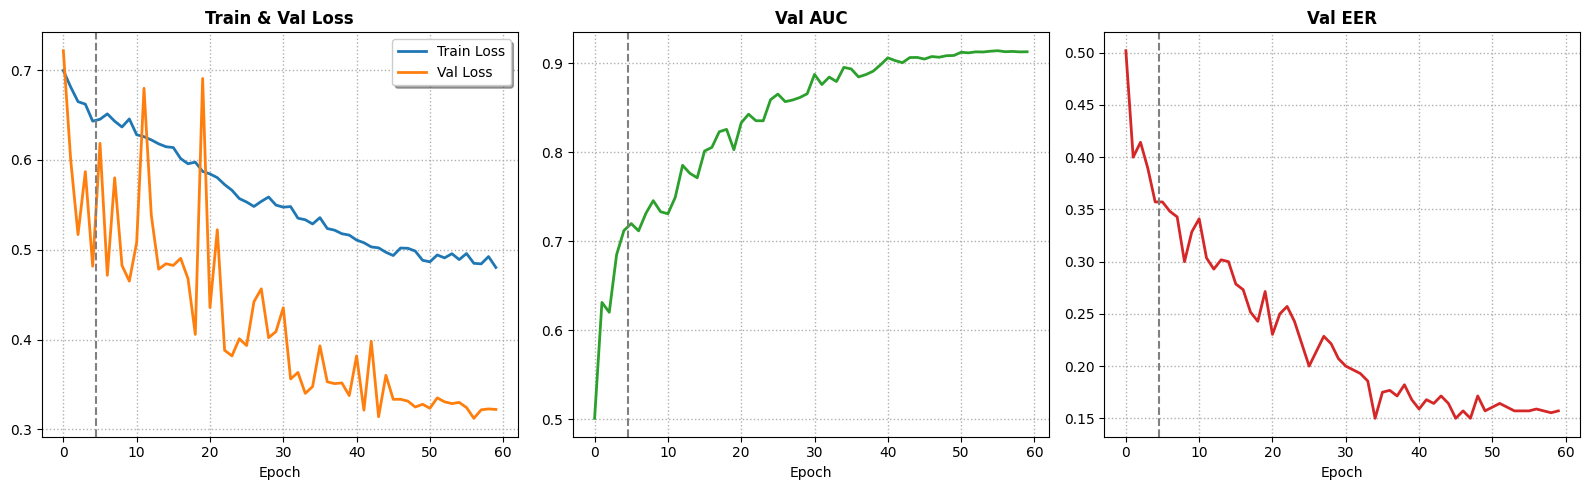

In [39]:
# ==================== BIỂU ĐỒ LỊCH SỬ HUẤN LUYỆN ====================
import matplotlib.pyplot as plt
import seaborn as sns

if os.path.exists(HISTORY_CSV):
    history_df = pd.read_csv(HISTORY_CSV)
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # Subplot 1: Train Loss and Val Loss
    if 'train_loss' in history_df.columns:
        axes[0].plot(history_df["train_loss"], label='Train Loss', color='#1f77b4', linewidth=2)
    if 'val_loss' in history_df.columns:
        axes[0].plot(history_df["val_loss"], label='Val Loss', color='#ff7f0e', linewidth=2)
    axes[0].set_title("Train & Val Loss", fontsize=12, fontweight='bold')
    axes[0].set_xlabel("Epoch")
    if len(history_df) > 5:
        axes[0].axvline(5 - 0.5, color="gray", linestyle="--")
    axes[0].legend(shadow=True, frameon=True)
    axes[0].grid(True, linestyle=':', linewidth=1)
    
    # Subplot 2: Val AUC
    if 'val_auc' in history_df.columns:
        axes[1].plot(history_df["val_auc"], color='#2ca02c', linewidth=2)
        axes[1].set_title("Val AUC", fontsize=12, fontweight='bold')
        axes[1].set_xlabel("Epoch")
        if len(history_df) > 5:
            axes[1].axvline(5 - 0.5, color="gray", linestyle="--")
        axes[1].grid(True, linestyle=':', linewidth=1)
        
    # Subplot 3: Val EER
    if 'val_eer' in history_df.columns:
        axes[2].plot(history_df["val_eer"], color='#d62728', linewidth=2)
        axes[2].set_title("Val EER", fontsize=12, fontweight='bold')
        axes[2].set_xlabel("Epoch")
        if len(history_df) > 5:
            axes[2].axvline(5 - 0.5, color="gray", linestyle="--")
        axes[2].grid(True, linestyle=':', linewidth=1)
        
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "training_history.png"))
    plt.show()
else:
    print(f"History CSV not found at {HISTORY_CSV}")


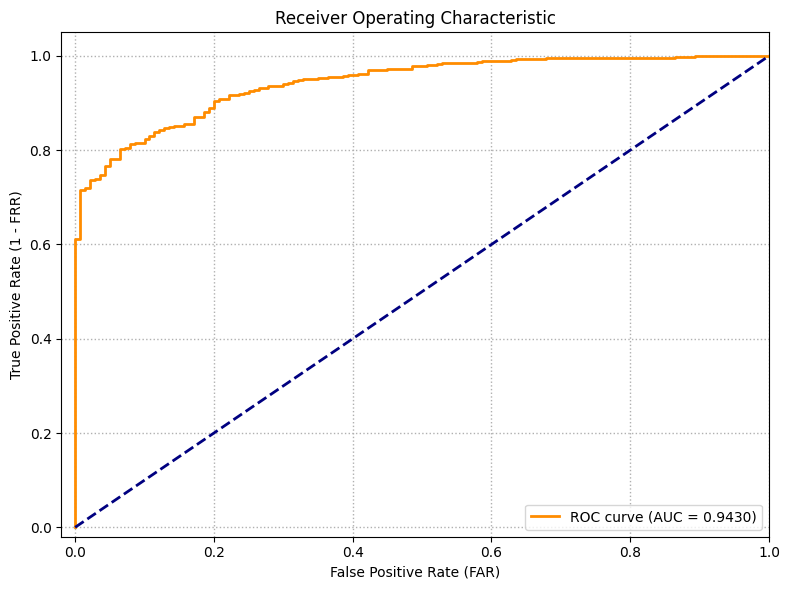

In [40]:
# ==================== BIỂU ĐỒ ROC ====================
fpr, tpr, thresholds = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([-0.02, 1.0])
plt.ylim([-0.02, 1.05])
plt.xlabel('False Positive Rate (FAR)')
plt.ylabel('True Positive Rate (1 - FRR)')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', linewidth=1)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "roc_curve.png"), dpi=150)
plt.show()

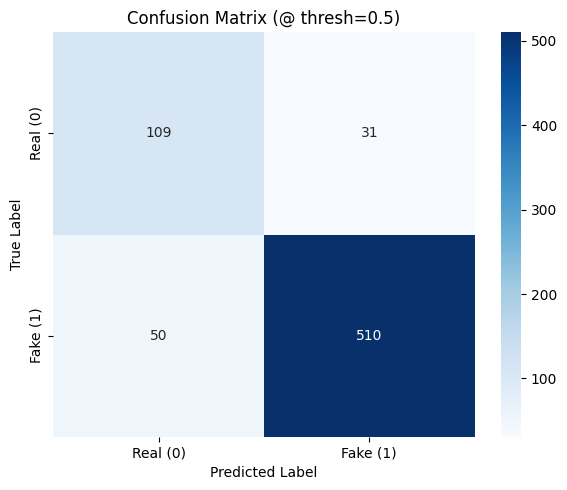

In [41]:
# ==================== CONFUSION MATRIX ====================
cm = metrics['cm_at_0.5']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, 
            xticklabels=['Real (0)', 'Fake (1)'], 
            yticklabels=['Real (0)', 'Fake (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (@ thresh=0.5)')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "confusion_matrix.png"), dpi=150)
plt.show()

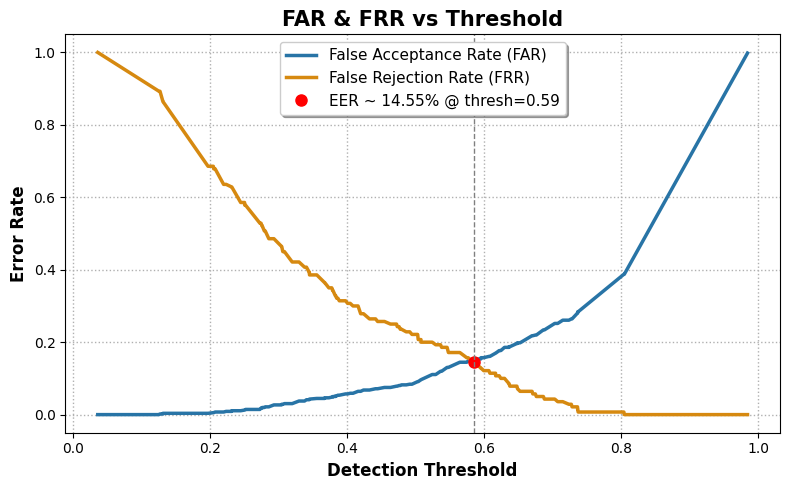

In [42]:
# ==================== BIỂU ĐỒ FAR/FRR ====================
fars, frrs = [], []
for thresh in thresholds:
    preds = (np.array(y_score) >= thresh).astype(int)
    cm_t = confusion_matrix(y_true, preds, labels=[0, 1])
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    far_t = fn_t / (fn_t + tp_t) if (fn_t + tp_t) > 0 else 0
    frr_t = fp_t / (fp_t + tn_t) if (fp_t + tn_t) > 0 else 0
    fars.append(far_t)
    frrs.append(frr_t)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, fars, color="#2874A6", lw=2.5, label='False Acceptance Rate (FAR)')
plt.plot(thresholds, frrs, color="#D68910", lw=2.5, label='False Rejection Rate (FRR)')

idx_eer = np.argmin(np.abs(np.array(fars) - np.array(frrs)))
eer_thresh = thresholds[idx_eer]
eer_val = (fars[idx_eer] + frrs[idx_eer]) / 2

plt.plot(eer_thresh, eer_val, 'ro', markersize=8, label=f'EER ~ {eer_val*100:.2f}% @ thresh={eer_thresh:.2f}')
plt.axvline(x=eer_thresh, color='gray', linestyle='--', lw=1)

plt.xlabel('Detection Threshold', fontsize=12, fontweight='bold')
plt.ylabel('Error Rate', fontsize=12, fontweight='bold')
plt.title('FAR & FRR vs Threshold', fontsize=15, fontweight='bold')
plt.legend(loc="upper center", fontsize=11, frameon=True, shadow=True)
plt.grid(True, linestyle=':', linewidth=1)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "far_frr_curve.png"), dpi=150)
plt.show()